# Week 5: Task 3 - Housing Price Prediction
## Feature Engineering, Feature Selection & Preprocessing (Wednesday & Thursday Deliverables)

### 1. Objectives
1. **Feature Engineering (Wednesday)**:
   - `rooms_per_household = total_rooms / households`
   - `bedrooms_per_room = total_bedrooms / total_rooms`
   - `population_per_household = population / households`
   - Compute correlation matrix and export heatmap to `outputs/correlation_heatmap.png`.
2. **Feature Selection & Preprocessing (Thursday)**:
   - Analyze correlation strength and select key predictive features.
   - Partition data into 80/20 train/test sets (`random_state=42`).
   - Standardize numerical features using `StandardScaler` (fit on train, transform on test).
   - Export preprocessed CSV files: `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

# Load cleaned dataset
DATA_PATH = Path("../outputs/housing_cleaned.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("week-5/outputs/housing_cleaned.csv")

df = pd.read_csv(DATA_PATH)
print(f"Cleaned dataset loaded. Shape: {df.shape}")

Cleaned dataset loaded. Shape: (20626, 14)

### 2. Feature Engineering
Creating interaction features that capture household density and room ratios:
- `rooms_per_household`: Average number of rooms per household in the district.
- `bedrooms_per_room`: Proportion of rooms that are bedrooms (indicators of property luxury/density).
- `population_per_household`: Average family/household size.

In [2]:
# Compute the 3 required ratio features
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

print("Engineered Features Summary Statistics:")
df[["rooms_per_household", "bedrooms_per_room", "population_per_household"]].describe()

       rooms_per_household  bedrooms_per_room  population_per_household
count         20626.000000       20626.000000              20626.000000
mean              5.427985           0.213829                  3.070379
std               2.474536           0.065254                 10.389519
min               0.846154           0.037151                  0.692308
25%               4.440082           0.175250                  2.429296
50%               5.227813           0.203192                  2.817800
75%               6.051634           0.240130                  3.282178
max             141.909091           2.824675               1243.333333

### 3. Correlation Analysis & Heatmap
Examine the Pearson correlation coefficients against the target `median_house_value`.

In [3]:
# Correlation against median_house_value
corr_series = df.corr()["median_house_value"].sort_values(ascending=False)
print("Features ranked by correlation with median_house_value:")
print(corr_series)

Features ranked by correlation with median_house_value:
median_house_value            1.000000
median_income                 0.687902
ocean_proximity_<1H OCEAN     0.256607
ocean_proximity_NEAR BAY      0.160440
rooms_per_household           0.151761
ocean_proximity_NEAR OCEAN    0.141803
total_rooms                   0.138517
housing_median_age            0.106274
households                    0.066023
total_bedrooms                0.049194
ocean_proximity_ISLAND        0.023428
population_per_household     -0.023736
population                   -0.028542
longitude                    -0.046071
latitude                     -0.144133
bedrooms_per_room            -0.233059
ocean_proximity_INLAND       -0.484894
Name: median_house_value, dtype: float64

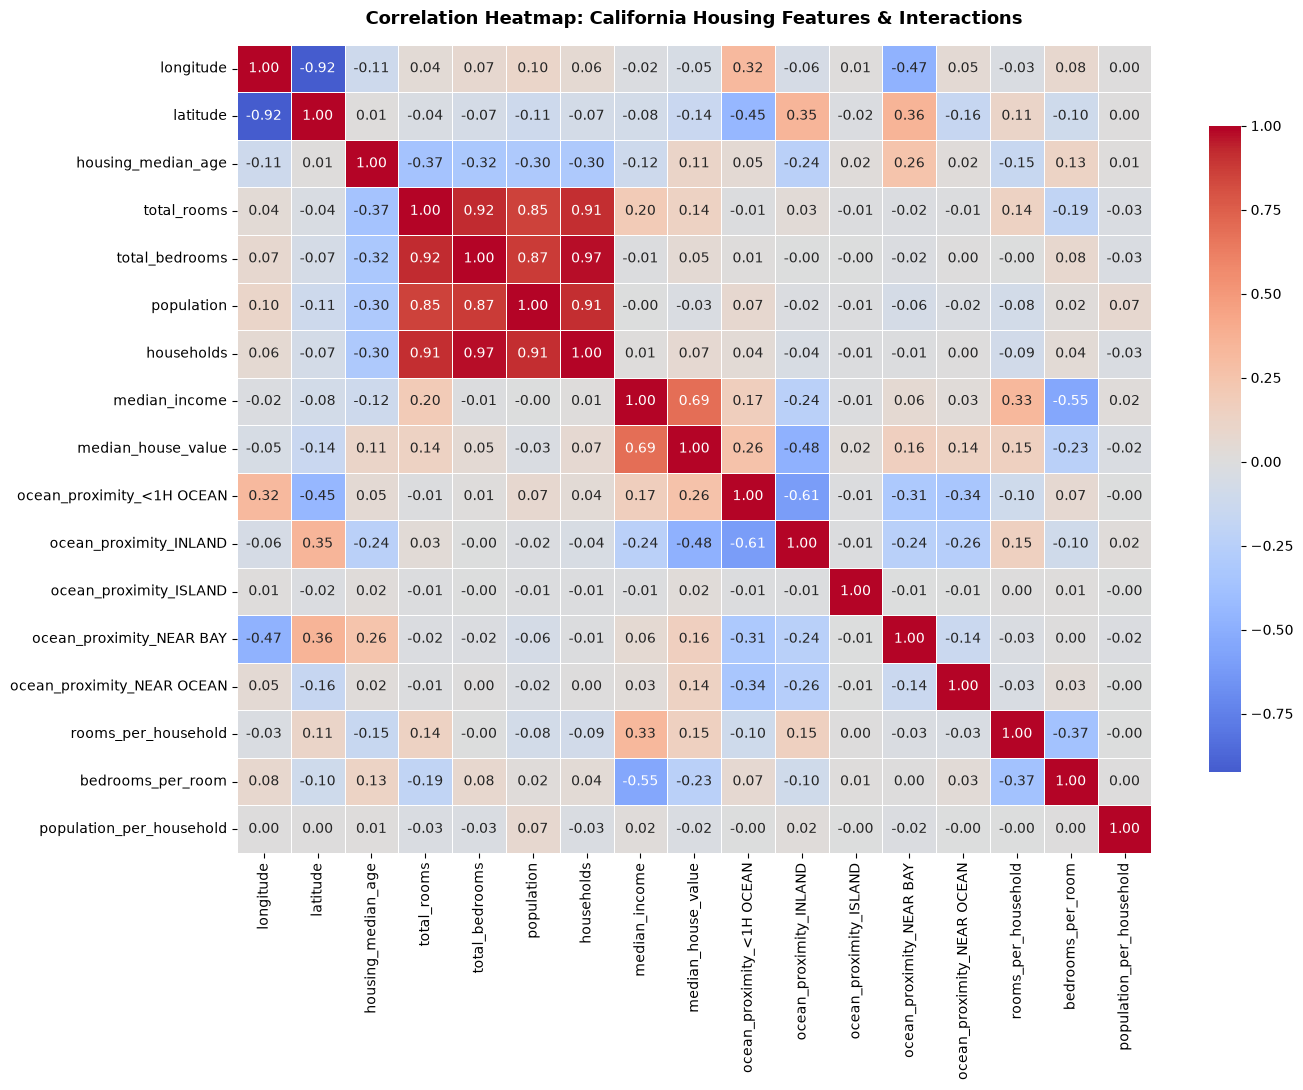

In [4]:
# Plot and save the correlation heatmap
plt.figure(figsize=(14, 11))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap: California Housing Features & Interactions", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()

# Save heatmap to outputs
heatmap_path = Path("../outputs/correlation_heatmap.png")
if not heatmap_path.parent.exists():
    heatmap_path = Path("week-5/outputs/correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

### 4. Feature Selection Rationale
Analyzing the correlation spectrum and domain relevance:

| Feature | Correlation with `median_house_value` | Rationale for Inclusion |
| :--- | :---: | :--- |
| **`median_income`** | **+0.688** | Strongest single predictor; household purchasing power directly governs house prices. |
| **`ocean_proximity_INLAND`** | **-0.485** | Strong negative predictor; inland properties are considerably cheaper than coastal properties. |
| **`ocean_proximity_<1H OCEAN`** | **+0.257** | Proximity to coastline/urban centers adds significant property premium. |
| **`bedrooms_per_room`** | **-0.233** | Strong engineered feature; higher bedroom ratio indicates lower socio-economic status or crowded housing. |
| **`ocean_proximity_NEAR BAY`** | **+0.160** | Highly desirable Silicon Valley / SF Bay Area real estate. |
| **`rooms_per_household`** | **+0.152** | Larger homes per household reflect higher property values. |
| **`latitude` & `longitude`** | **-0.144 / -0.046** | Geographic coordinates form spatial pair capturing coastal proximity and microclimates. |
| **`ocean_proximity_NEAR OCEAN`** | **+0.142** | Coastal premium for beach-adjacent neighborhoods. |
| **`total_rooms`** | **+0.138** | Neighborhood scale and property volume. |
| **`housing_median_age`** | **+0.106** | Historical architecture and mature infrastructure. |
| **`households`** | **+0.066** | District residential density indicator. |
| **`ocean_proximity_ISLAND`** | **+0.023** | Completes one-hot encoded representation for location. |

Selected feature set combines all high/moderate correlation indicators and coordinate pairs to guarantee spatial integrity.

In [5]:
# Define selected features
selected_features = ['median_income', 'ocean_proximity_INLAND', 'ocean_proximity_<1H OCEAN', 'bedrooms_per_room', 'rooms_per_household', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'total_rooms', 'housing_median_age', 'latitude', 'longitude', 'households', 'ocean_proximity_ISLAND']

X = df[selected_features]
y = df["median_house_value"]

# Train/test split (80/20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (16500, 13), y_train shape: (16500,)
X_test shape: (4126, 13), y_test shape: (4126,)

### 5. Numerical Feature Scaling (StandardScaler)
To prevent data leakage, `StandardScaler` is fitted **strictly on `X_train`** and then applied to transform both `X_train` and `X_test`. Binary one-hot encoded indicators remain in {0, 1} format.

In [6]:
numerical_cols_to_scale = ['median_income', 'bedrooms_per_room', 'rooms_per_household', 'total_rooms', 'housing_median_age', 'latitude', 'longitude', 'households']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit only on train, transform train and test
X_train_scaled[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test_scaled[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("Sample scaled feature values (X_train_scaled):")
X_train_scaled.head(3)

      median_income  ocean_proximity_INLAND  ...  households  ocean_proximity_ISLAND
6097       0.560551                       0  ...   -0.690655                       0
6045      -0.379240                       1  ...    0.851374                       0
6667       0.180481                       1  ...   -0.165709                       0

[3 rows x 13 columns]

### 6. Exporting Preprocessed Datasets
Save `X_train.csv`, `X_test.csv`, `y_train.csv`, and `y_test.csv` to `outputs/` for baseline modeling.

In [7]:
out_dir = Path("../outputs")
if not out_dir.exists():
    out_dir = Path("week-5/outputs")

X_train_scaled.to_csv(out_dir / "X_train.csv", index=False)
X_test_scaled.to_csv(out_dir / "X_test.csv", index=False)
y_train.to_csv(out_dir / "y_train.csv", index=False)
y_test.to_csv(out_dir / "y_test.csv", index=False)

print("Preprocessed files successfully exported:")
for name in ["X_train.csv", "X_test.csv", "y_train.csv", "y_test.csv"]:
    p = out_dir / name
    print(f" - {name} ({p.stat().st_size:,} bytes)")

Preprocessed files successfully exported:
 - X_train.csv
 - X_test.csv
 - y_train.csv
 - y_test.csv